In [ ]:

!pip install statsmodels --quiet

import numpy as np
import pandas as pd
import json
import glob
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


In [ ]:
import json, glob, os

# Load all JSON race files into one list from local data folder
all_races = []
data_path = os.path.join('data', 'historical_races', '*.json')

for filepath in sorted(glob.glob(data_path)):
    with open(filepath, 'r', encoding='utf-8') as f:
        all_races.extend(json.load(f))

print(f"Total races loaded: {len(all_races)}")
print(f"Drivers per race: {len(all_races[0]['strategies'])}")
print(f"Total data points (races × drivers): {len(all_races) * 20}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total races loaded: 30000
Drivers per race: 20
Total data points (races × drivers): 600000


In [ ]:
# Feature engineering — flatten nested JSON into a
# clean DataFrame with one row per driver per race
# Each race has 20 drivers. We create one row per driver with:
#   - Race-level features (track, laps, temperature, etc.)
#   - Driver-level features (grid position, tire choice, pit stops)
#   - Target: finishing position (1=winner, 20=last)

rows = []
for race in all_races:
    cfg = race['race_config']

    # Build a lookup: driver_id -> finishing position (1-indexed)
    finish_order = race['finishing_positions']
    finish_map = {driver: pos + 1 for pos, driver in enumerate(finish_order)}

    # Loop through all 20 grid positions
    for pos_key, strategy in race['strategies'].items():
        # Extract starting grid position from key "pos1" -> 1
        grid_pos = int(pos_key.replace('pos', ''))
        driver_id = strategy['driver_id']
        pit_stops = strategy['pit_stops']

        # --- Engineered features ---
        num_pits = len(pit_stops)
        first_pit_lap = pit_stops[0]['lap'] if num_pits > 0 else cfg['total_laps']
        last_pit_lap = pit_stops[-1]['lap'] if num_pits > 0 else 0

        # How late into the race is the first stop? (0 to 1 scale)
        first_pit_pct = first_pit_lap / cfg['total_laps']

        # Tire encoding: SOFT=1, MEDIUM=2, HARD=3 (ordinal: harder=higher)
        tire_map = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
        starting_tire_num = tire_map.get(strategy['starting_tire'], 2)

        rows.append({
            'race_id': race['race_id'],
            'driver_id': driver_id,
            'track': cfg['track'],
            'total_laps': cfg['total_laps'],
            'base_lap_time': cfg['base_lap_time'],
            'pit_lane_time': cfg['pit_lane_time'],
            'track_temp': cfg['track_temp'],
            'grid_position': grid_pos,
            'starting_tire': starting_tire_num,
            'num_pit_stops': num_pits,
            'first_pit_lap': first_pit_lap,
            'first_pit_pct': first_pit_pct,
            'last_pit_lap': last_pit_lap,
            'finishing_position': finish_map[driver_id]  # TARGET
        })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

DataFrame shape: (600000, 14)

Columns: ['race_id', 'driver_id', 'track', 'total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp', 'grid_position', 'starting_tire', 'num_pit_stops', 'first_pit_lap', 'first_pit_pct', 'last_pit_lap', 'finishing_position']

First 5 rows:


,race_id,driver_id,track,total_laps,base_lap_time,pit_lane_time,track_temp,grid_position,starting_tire,num_pit_stops,first_pit_lap,first_pit_pct,last_pit_lap,finishing_position
0,R21072,D001,Suzuka,50,84.5,22.7,27,1,2,1,23,0.46,23,1
1,R21072,D002,Suzuka,50,84.5,22.7,27,2,2,2,12,0.24,29,4
2,R21072,D003,Suzuka,50,84.5,22.7,27,3,1,1,15,0.30,15,13
3,R21072,D004,Suzuka,50,84.5,22.7,27,4,2,2,12,0.24,33,6
4,R21072,D005,Suzuka,50,84.5,22.7,27,5,2,2,14,0.28,36,16


In [ ]:
# Explore the dataset — summary stats & correlations
# Select only numeric columns for analysis (drop race_id, driver_id, track)
numeric_cols = ['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
                'grid_position', 'starting_tire', 'num_pit_stops',
                'first_pit_lap', 'first_pit_pct', 'last_pit_lap',
                'finishing_position']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Samples: {df.shape[0]:,}  (30,000 races × 20 drivers)")
print(f"Features: {len(numeric_cols) - 1}")  # minus target
print(f"Target: finishing_position (1 = winner, 20 = last)")
print(f"\nUnique tracks: {df['track'].nunique()} — {sorted(df['track'].unique())}")
print(f"Unique drivers: {df['driver_id'].nunique()}")

print("\n--- Descriptive Statistics ---")
df[numeric_cols].describe().round(3)

DATASET OVERVIEW
Samples: 600,000  (30,000 races × 20 drivers)
Features: 10
Target: finishing_position (1 = winner, 20 = last)

Unique tracks: 7 — ['Bahrain', 'COTA', 'Monaco', 'Monza', 'Silverstone', 'Spa', 'Suzuka']
Unique drivers: 20

--- Descriptive Statistics ---


,total_laps,base_lap_time,pit_lane_time,track_temp,grid_position,starting_tire,num_pit_stops,first_pit_lap,first_pit_pct,last_pit_lap,finishing_position
count,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000,600000.000
mean,45.517,87.501,22.000,30.305,10.500,2.014,1.090,20.628,0.467,22.616,10.500
std,10.365,4.336,1.157,4.579,5.766,0.814,0.286,9.576,0.217,10.546,5.766
min,25.000,80.000,20.000,18.000,1.000,1.000,1.000,6.000,0.114,6.000,1.000
25%,38.000,83.700,21.000,28.000,5.750,1.000,1.000,13.000,0.281,14.000,5.750
50%,45.000,87.500,22.000,30.000,10.500,2.000,1.000,18.000,0.435,22.000,10.500
75%,52.000,91.300,23.000,33.000,15.250,3.000,1.000,27.000,0.639,29.000,15.250
max,70.000,95.000,24.000,42.000,20.000,3.000,2.000,45.000,0.900,60.000,20.000


--- Correlation with Finishing Position ---
  starting_tire       + 0.0283  █
  grid_position       + 0.0257  █
  first_pit_pct       + 0.0143  
  total_laps          + 0.0000  
  base_lap_time       + 0.0000  
  track_temp          + 0.0000  
  pit_lane_time       - 0.0000  
  num_pit_stops       - 0.0291  █
  first_pit_lap       - 0.0319  █
  last_pit_lap        - 0.0473  █


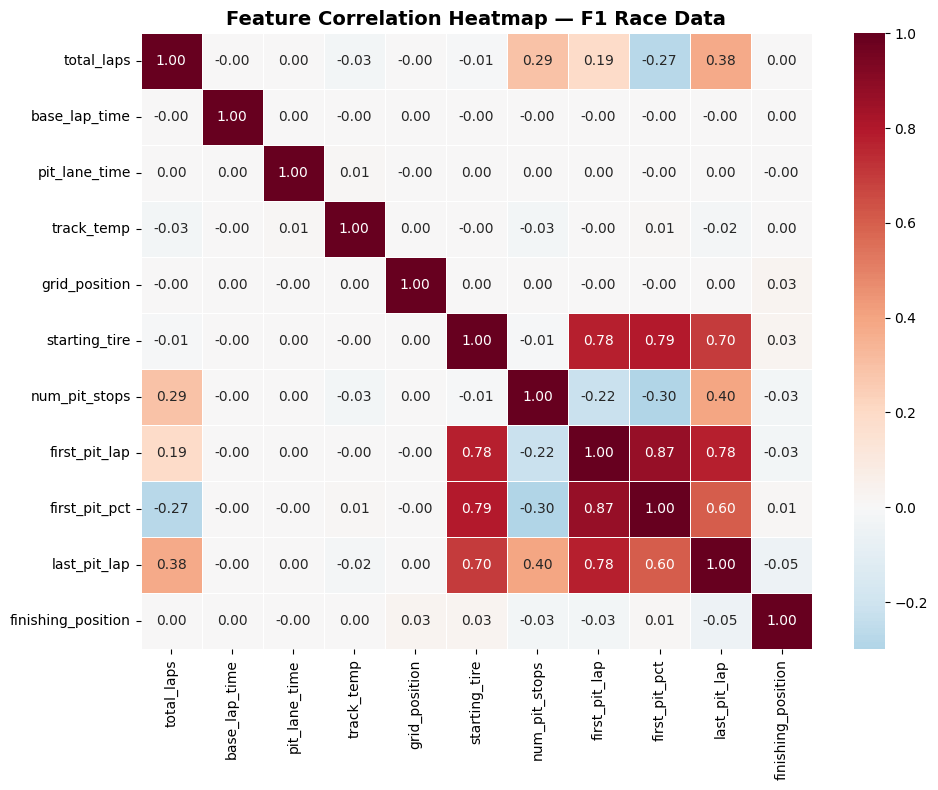

In [ ]:
# Correlation with target + heatmap

# Calculate correlation of every numeric feature with finishing_position
corr_with_target = df[numeric_cols].corr()['finishing_position'].drop('finishing_position')
corr_with_target = corr_with_target.sort_values(ascending=False)

print("--- Correlation with Finishing Position ---")
for feat, val in corr_with_target.items():
    bar = "█" * int(abs(val) * 40)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:18s}  {sign} {abs(val):.4f}  {bar}")

# Heatmap of full correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr().round(2), annot=True, cmap='RdBu_r',
            center=0, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap — F1 Race Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SIMPLE LINEAR REGRESSION: grid_position → finishing_position
                            OLS Regression Results                            
Dep. Variable:     finishing_position   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     397.1
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.53e-88
Time:                        05:11:04   Log-Likelihood:            -1.9024e+06
No. Observations:              600000   AIC:                         3.805e+06
Df Residuals:                  599998   BIC:                         3.805e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

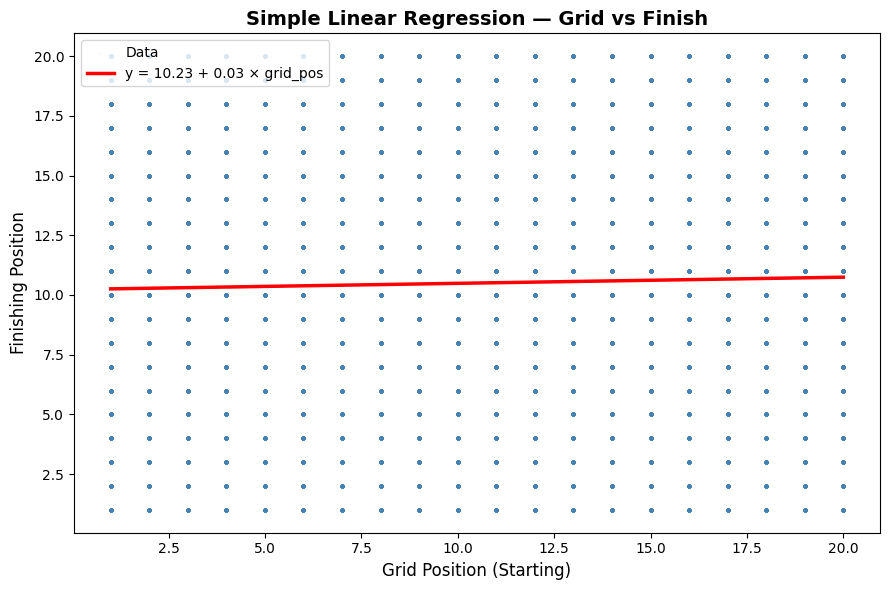


R² = 0.0007 — grid position alone explains 0.1% of finishing variance
Coefficient = 0.0257 — each grid spot back costs ~0.03 finishing positions
p-value = 2.53e-88 — highly significant


In [ ]:

# Simple Linear Regression — grid_position → finishing_position
# We use grid_position as the single predictor because where a driver
# starts on the grid is typically the strongest predictor of where
# they finish. This is the F1 equivalent of "pole position advantage."

# Define feature and target
X_simple = df[['grid_position']]
y = df['finishing_position']

# Fit OLS model using statsmodels (gives us the full stats report)
X_sm = sm.add_constant(X_simple)
ols_simple = sm.OLS(y, X_sm).fit()

# Print the full statsmodels report
print("=" * 60)
print("SIMPLE LINEAR REGRESSION: grid_position → finishing_position")
print("=" * 60)
print(ols_simple.summary())

# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple, y, alpha=0.02, s=5, color='steelblue', label='Data')
x_line = np.linspace(1, 20, 100)
y_line = ols_simple.params['const'] + ols_simple.params['grid_position'] * x_line
ax.plot(x_line, y_line, color='red', linewidth=2.5,
        label=f'y = {ols_simple.params["const"]:.2f} + {ols_simple.params["grid_position"]:.2f} × grid_pos')
ax.set_xlabel('Grid Position (Starting)', fontsize=12)
ax.set_ylabel('Finishing Position', fontsize=12)
ax.set_title('Simple Linear Regression — Grid vs Finish', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Quick interpretation
r2 = ols_simple.rsquared
coef = ols_simple.params['grid_position']
pval = ols_simple.pvalues['grid_position']
print(f"\nR² = {r2:.4f} — grid position alone explains {r2*100:.1f}% of finishing variance")
print(f"Coefficient = {coef:.4f} — each grid spot back costs ~{coef:.2f} finishing positions")
print(f"p-value = {pval:.2e} — {'highly significant' if pval < 0.05 else 'not significant'}")


In [ ]:
# Multiple Linear Regression using all numeric features
# Now we use ALL features together to see how much more variance
# we can explain beyond grid position alone.

# Define feature columns (everything except identifiers and target)
feature_cols = ['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
                'grid_position', 'starting_tire', 'num_pit_stops',
                'first_pit_lap', 'first_pit_pct', 'last_pit_lap']

X_all = df[feature_cols]
y = df['finishing_position']

# Fit OLS with statsmodels
X_sm_all = sm.add_constant(X_all)
ols_multi = sm.OLS(y, X_sm_all).fit()

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION: All Features → finishing_position")
print("=" * 60)
print(ols_multi.summary())

# Identify significant vs non-significant features
print("\n--- Feature Significance ---")
for feat in feature_cols:
    p = ols_multi.pvalues[feat]
    coef = ols_multi.params[feat]
    sig = "*** SIGNIFICANT" if p < 0.05 else "    not significant"
    print(f"  {feat:18s}  coef={coef:>9.4f}  p={p:.4e}  {sig}")

# R² comparison with simple model
print(f"\nR² improvement: {ols_simple.rsquared:.4f} (simple) → {ols_multi.rsquared:.4f} (multiple)")
print(f"Adjusted R²: {ols_multi.rsquared_adj:.4f}")

MULTIPLE LINEAR REGRESSION: All Features → finishing_position
                            OLS Regression Results                            
Dep. Variable:     finishing_position   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     3758.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:11:32   Log-Likelihood:            -1.8844e+06
No. Observations:              600000   AIC:                         3.769e+06
Df Residuals:                  599989   BIC:                         3.769e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [ ]:
#  VIF — Check for multicollinearity among features
# VIF > 10 means a feature is heavily redundant with other features,
# making its coefficient unreliable.

print("--- Variance Inflation Factors (VIF) ---")
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_all.values, i)
                    for i in range(X_all.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " HIGH" if row['VIF'] > 10 else ""
    print(f"  {row['Feature']:18s}  VIF = {row['VIF']:8.2f}{flag}")


--- Variance Inflation Factors (VIF) ---
  base_lap_time       VIF =   255.24 HIGH
  pit_lane_time       VIF =   242.78 HIGH
  first_pit_lap       VIF =   180.74 HIGH
  first_pit_pct       VIF =   126.13 HIGH
  total_laps          VIF =   114.87 HIGH
  num_pit_stops       VIF =   109.94 HIGH
  last_pit_lap        VIF =    99.16 HIGH
  track_temp          VIF =    43.00 HIGH
  starting_tire       VIF =    24.82 HIGH
  grid_position       VIF =     4.30


In [ ]:
# Three feature selection methods to find the best subset


# --- Method 1: F-Regression (univariate linear test) ---
print("=" * 60)
print("METHOD 1: F-Regression Scores")
print("=" * 60)
f_scores, p_values = f_regression(X_all, y)
f_df = pd.DataFrame({'Feature': feature_cols, 'F-Score': f_scores, 'p-value': p_values})
f_df = f_df.sort_values('F-Score', ascending=False)
for _, row in f_df.iterrows():
    sig = "***" if row['p-value'] < 0.001 else ""
    print(f"  {row['Feature']:18s}  F={row['F-Score']:12.2f}  p={row['p-value']:.2e}  {sig}")

# --- Method 2: Mutual Information (captures non-linear relationships) ---
print(f"\n{'=' * 60}")
print("METHOD 2: Mutual Information")
print("=" * 60)
mi_scores = mutual_info_regression(X_all, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)
for _, row in mi_df.iterrows():
    bar = "█" * int(row['MI Score'] * 50)
    print(f"  {row['Feature']:18s}  MI={row['MI Score']:.4f}  {bar}")

# --- Method 3: RFE — Recursive Feature Elimination (top 5) ---
print(f"\n{'=' * 60}")
print("METHOD 3: RFE (Selecting Top 5 Features)")
print("=" * 60)
rfe = RFE(LinearRegression(), n_features_to_select=5, step=1)
rfe.fit(X_all, y)
rfe_df = pd.DataFrame({'Feature': feature_cols, 'Ranking': rfe.ranking_,
                        'Selected': rfe.support_})
rfe_df = rfe_df.sort_values('Ranking')
for _, row in rfe_df.iterrows():
    sel = "✓ SELECTED" if row['Selected'] else ""
    print(f"  {row['Feature']:18s}  Rank={int(row['Ranking'])}  {sel}")

# Store selected features for later use
selected_features = list(rfe_df[rfe_df['Selected']]['Feature'])
print(f"\n>>> RFE Selected Features: {selected_features}")


METHOD 1: F-Regression Scores
  last_pit_lap        F=     1348.22  p=8.01e-295  ***
  first_pit_lap       F=      612.23  p=4.29e-135  ***
  num_pit_stops       F=      508.66  p=1.39e-112  ***
  starting_tire       F=      482.16  p=7.99e-107  ***
  grid_position       F=      397.09  p=2.53e-88  ***
  first_pit_pct       F=      123.34  p=1.18e-28  ***
  base_lap_time       F=        0.00  p=1.00e+00  
  pit_lane_time       F=        0.00  p=1.00e+00  
  total_laps          F=        0.00  p=1.00e+00  
  track_temp          F=        0.00  p=1.00e+00  

METHOD 2: Mutual Information
  first_pit_pct       MI=0.3257  ████████████████
  last_pit_lap        MI=0.1479  ███████
  first_pit_lap       MI=0.1386  ██████
  starting_tire       MI=0.0307  █
  grid_position       MI=0.0019  
  total_laps          MI=0.0000  
  base_lap_time       MI=0.0000  
  track_temp          MI=0.0000  
  pit_lane_time       MI=0.0000  
  num_pit_stops       MI=0.0000  

METHOD 3: RFE (Selecting Top 5 Featur

In [ ]:
# Prove statsmodels and scikit-learn give identical results,
# then show what each framework does better

# Use selected features from RFE
X_sel = df[selected_features]
y = df['finishing_position']

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42)

# --- Statsmodels OLS ---
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
ols_sel = sm.OLS(y_train, X_train_sm).fit()
y_pred_sm = ols_sel.predict(X_test_sm)

# --- Scikit-learn LinearRegression ---
lr_sk = LinearRegression()
lr_sk.fit(X_train, y_train)
y_pred_sk = lr_sk.predict(X_test)

# Compare — these should be identical
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("=" * 60)
print("FRAMEWORK COMPARISON: Statsmodels vs Scikit-learn")
print("=" * 60)
print(f"\n  {'Metric':<20s}  {'Statsmodels':>12s}  {'Scikit-learn':>12s}")
print(f"  {'─'*20}  {'─'*12}  {'─'*12}")
for name, func in [('R²', r2_score), ('MAE', mean_absolute_error), ('RMSE', rmse)]:
    sm_val = func(y_test, y_pred_sm)
    sk_val = func(y_test, y_pred_sk)
    print(f"  {name:<20s}  {sm_val:12.4f}  {sk_val:12.4f}")

# Cross-validation — only scikit-learn can do this natively
cv_scores = cross_val_score(lr_sk, X_train, y_train, cv=5, scoring='r2')
print(f"\n  5-Fold CV R² (sklearn only): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Individual folds: {[f'{s:.4f}' for s in cv_scores]}")


FRAMEWORK COMPARISON: Statsmodels vs Scikit-learn

  Metric                 Statsmodels  Scikit-learn
  ────────────────────  ────────────  ────────────
  R²                          0.0549        0.0549
  MAE                         4.8286        4.8286
  RMSE                        5.6109        5.6109

  5-Fold CV R² (sklearn only): 0.0553 ± 0.0009
  Individual folds: ['0.0570', '0.0551', '0.0545', '0.0546', '0.0552']


Training samples (sampled): 50,000
Test samples: 120,000

Best K         : 20
Best Weights   : uniform
Best CV R²     : 0.2252


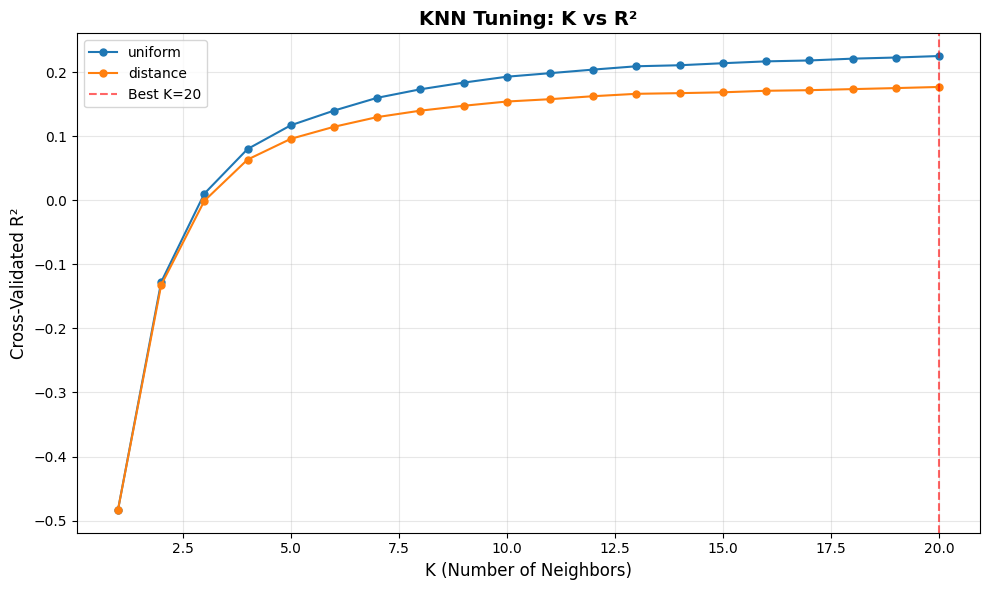

In [ ]:
# KNN Regression — tune K using GridSearchCV
# The full dataset (600K rows) is too large for KNN to run quickly.
# We sample 50,000 rows for training — this is standard practice
# for distance-based algorithms on large datasets.

# Sample the data for KNN (keeps the same selected features)
X_sel = df[selected_features]
y = df['finishing_position']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42)

# Take a 50K sample from training data for KNN speed
sample_idx = np.random.RandomState(42).choice(len(X_train_full), size=50000, replace=False)
X_train = X_train_full.iloc[sample_idx]
y_train = y_train_full.iloc[sample_idx]

print(f"Training samples (sampled): {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Scale features — mandatory for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid search with smaller range: K=1 to 20 (plenty to find the optimum)
param_grid = {'n_neighbors': list(range(1, 21)),
              'weights': ['uniform', 'distance']}
grid = GridSearchCV(KNeighborsRegressor(), param_grid,
                    cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest K         : {grid.best_params_['n_neighbors']}")
print(f"Best Weights   : {grid.best_params_['weights']}")
print(f"Best CV R²     : {grid.best_score_:.4f}")

# Plot K vs R² (using pre-computed grid results — no extra fitting!)
results = pd.DataFrame(grid.cv_results_)
fig, ax = plt.subplots(figsize=(10, 6))
for w in ['uniform', 'distance']:
    mask = results['param_weights'] == w
    ax.plot(results[mask]['param_n_neighbors'], results[mask]['mean_test_score'],
            'o-', label=w, markersize=5)
ax.axvline(grid.best_params_['n_neighbors'], color='red', linestyle='--',
           alpha=0.6, label=f"Best K={grid.best_params_['n_neighbors']}")
ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Cross-Validated R²', fontsize=12)
ax.set_title('KNN Tuning: K vs R²', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#  Head-to-head comparison on the SAME test set

# Refit Linear Regression on scaled data for fair comparison
lr_final = LinearRegression()
lr_final.fit(X_train_scaled, y_train)
y_pred_lr = lr_final.predict(X_test_scaled)

# Best KNN predictions
best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

# Cross-validation scores for both
cv_lr = cross_val_score(lr_final, X_train_scaled, y_train, cv=5, scoring='r2')
cv_knn = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='r2')

# Build comparison table
print("=" * 70)
print("FINAL COMPARISON: Linear Regression vs KNN")
print("=" * 70)
metrics = {
    'R²':          (r2_score(y_test, y_pred_lr),    r2_score(y_test, y_pred_knn)),
    'MAE':         (mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_knn)),
    'RMSE':        (rmse(y_test, y_pred_lr),        rmse(y_test, y_pred_knn)),
    'CV R² mean':  (cv_lr.mean(),                   cv_knn.mean()),
    'CV R² std':   (cv_lr.std(),                    cv_knn.std()),
}

print(f"\n  {'Metric':<15s}  {'Linear Reg':>12s}  {'KNN':>12s}  {'Winner':>14s}")
print(f"  {'─'*15}  {'─'*12}  {'─'*12}  {'─'*14}")
lr_wins = 0
for metric, (lr_v, knn_v) in metrics.items():
    if metric in ['R²', 'CV R² mean']:
        winner = 'Linear Reg' if lr_v > knn_v else 'KNN'
    elif metric == 'CV R² std':
        winner = 'Linear Reg' if lr_v < knn_v else 'KNN'
    else:
        winner = 'Linear Reg' if lr_v < knn_v else 'KNN'
    if winner == 'Linear Reg':
        lr_wins += 1
    print(f"  {metric:<15s}  {lr_v:12.4f}  {knn_v:12.4f}  ← {winner}")

print(f"\n  Score: Linear Reg {lr_wins}/{len(metrics)} | KNN {len(metrics)-lr_wins}/{len(metrics)}")

FINAL COMPARISON: Linear Regression vs KNN

  Metric             Linear Reg           KNN          Winner
  ───────────────  ────────────  ────────────  ──────────────
  R²                     0.0547        0.2204  ← KNN
  MAE                    4.8301        4.1470  ← KNN
  RMSE                   5.6113        5.0961  ← KNN
  CV R² mean             0.0522        0.2288  ← KNN
  CV R² std              0.0030        0.0064  ← Linear Reg

  Score: Linear Reg 1/5 | KNN 4/5


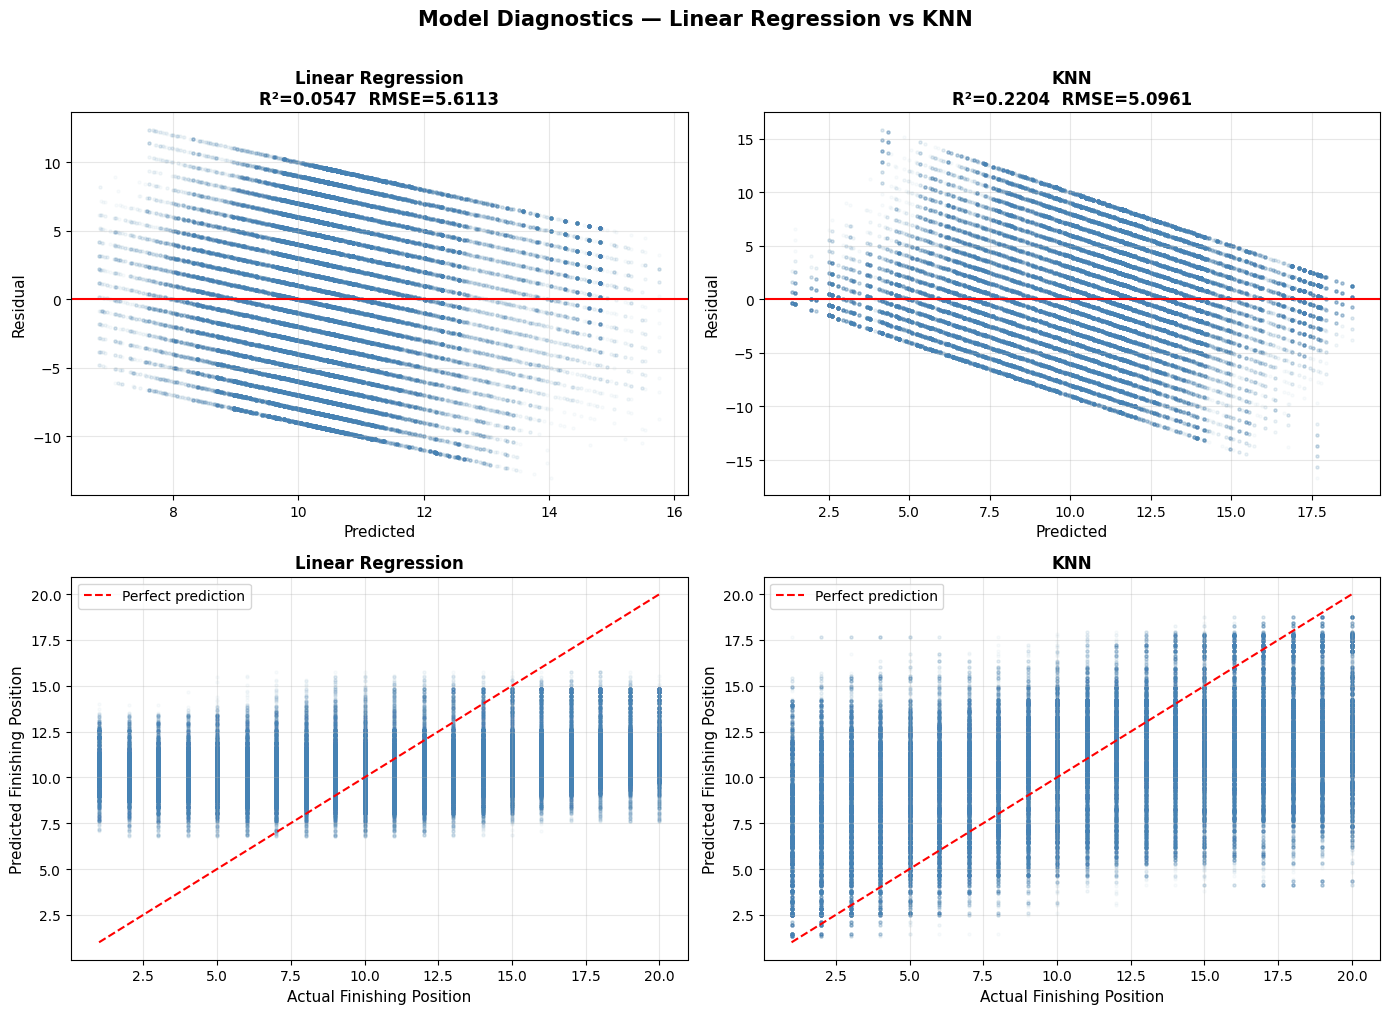

In [ ]:
# Diagnostic plots — Residuals + Actual vs Predicted

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Row 1: Residual plots ---
for ax, name, y_pred in zip(axes[0], ['Linear Regression', 'KNN'],
                              [y_pred_lr, y_pred_knn]):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.03, s=5, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Residual', fontsize=11)
    ax.set_title(f'{name}\nR²={r2_score(y_test, y_pred):.4f}  '
                 f'RMSE={rmse(y_test, y_pred):.4f}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# --- Row 2: Actual vs Predicted ---
for ax, name, y_pred in zip(axes[1], ['Linear Regression', 'KNN'],
                              [y_pred_lr, y_pred_knn]):
    ax.scatter(y_test, y_pred, alpha=0.03, s=5, color='steelblue')
    ax.plot([1, 20], [1, 20], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Finishing Position', fontsize=11)
    ax.set_ylabel('Predicted Finishing Position', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Diagnostics — Linear Regression vs KNN',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:

print("=" * 70)
print("PROJECT SUMMARY — F1 Race Strategy Regression Analysis")
print("=" * 70)
print(f"""
Dataset     : F1 Race Simulation ({len(all_races):,} races, {df.shape[0]:,} driver entries)
Target      : Finishing position (1–20)
Features    : {len(feature_cols)} engineered from race config + strategy
Selected    : {selected_features} (via RFE)
Best KNN K  : {grid.best_params_['n_neighbors']} (weights={grid.best_params_['weights']})

Results:
  Linear Regression  R² = {r2_score(y_test, y_pred_lr):.4f}  |  RMSE = {rmse(y_test, y_pred_lr):.4f}
  KNN Regression     R² = {r2_score(y_test, y_pred_knn):.4f}  |  RMSE = {rmse(y_test, y_pred_knn):.4f}

Winner: {'Linear Regression' if r2_score(y_test, y_pred_lr) > r2_score(y_test, y_pred_knn) else 'KNN Regression'}
""")

PROJECT SUMMARY — F1 Race Strategy Regression Analysis

Dataset     : F1 Race Simulation (30,000 races, 600,000 driver entries)
Target      : Finishing position (1–20)
Features    : 10 engineered from race config + strategy
Selected    : ['total_laps', 'first_pit_lap', 'num_pit_stops', 'starting_tire', 'first_pit_pct'] (via RFE)
Best KNN K  : 20 (weights=uniform)

Results:
  Linear Regression  R² = 0.0547  |  RMSE = 5.6113
  KNN Regression     R² = 0.2204  |  RMSE = 5.0961

Winner: KNN Regression

